In [2]:
import scanpy as sc
import anndata as ad
import decoupler as dc
import gseapy as gp
import os
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
#### Read in file 

adata_query_X =ad.read_h5ad("/tscc/lustre/ddn/scratch/aopatel/adata_mtg_Finalized.h5ad")

In [6]:
adata_query_X

AnnData object with n_obs × n_vars = 640321 × 36280
    obs: '10X_ID', 'sample_index', 'assay', 'specimenID', 'platform', 'RIN', 'rnaBatch', 'libraryBatch', 'sequencingBatch', 'individualID', 'tissue', 'samplingAge', 'nucleicAcidSource', 'sex', 'ADNC', 'Braak', 'CERAD', 'Thal phase', 'Cognitive status', 'Consensus clinical diagnosis', 'dataset', 'pmi', 'Severely Affected Donor', 'Continuous Pseudo-progression Score', 'age_numeric', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'dd_doublet', 'dd_score', 'full_leiden', 'cluster_flagged', 'predictions', 'sub_class_prob_max', 'is_high_confidence_95', 'is_high_confidence_90', 'is_high_confidence_85', 'neuronal_score', 'non_neur

In [23]:
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


In [24]:
dc.mt.ulm(data=adata_query_X, net=collectri)

In [26]:
score = dc.pp.get_obsm(adata=adata_query_X, key="score_ulm")
score

AnnData object with n_obs × n_vars = 640321 × 767
    obs: '10X_ID', 'sample_index', 'assay', 'specimenID', 'platform', 'RIN', 'rnaBatch', 'libraryBatch', 'sequencingBatch', 'individualID', 'tissue', 'samplingAge', 'nucleicAcidSource', 'sex', 'ADNC', 'Braak', 'CERAD', 'Thal phase', 'Cognitive status', 'Consensus clinical diagnosis', 'dataset', 'pmi', 'Severely Affected Donor', 'Continuous Pseudo-progression Score', 'age_numeric', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'dd_doublet', 'dd_score', 'full_leiden', 'cluster_flagged', 'predictions', 'sub_class_prob_max', 'is_high_confidence_95', 'is_high_confidence_90', 'is_high_confidence_85', 'neuronal_score', 'non_neuron

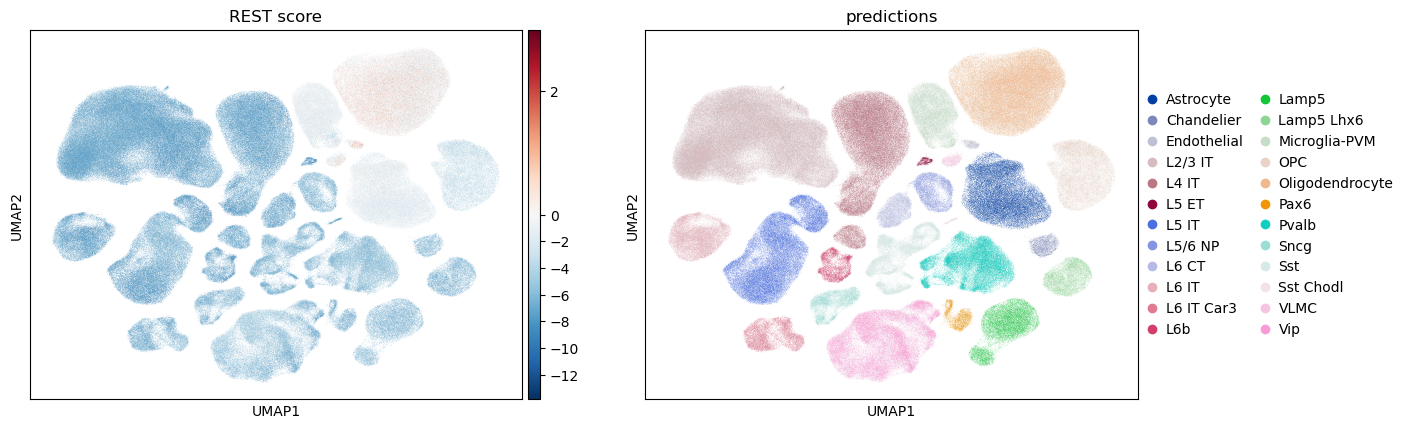

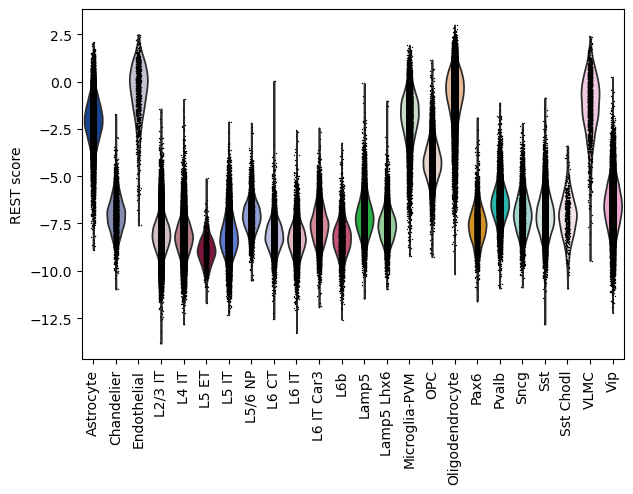

In [28]:
tf = "REST"
sc.pl.umap(score, color=[tf, "predictions"], cmap="RdBu_r", vcenter=0, title=[f"{tf} score", "predictions"])
sc.pl.violin(score, keys=[tf], groupby="predictions", rotation=90, ylabel=f"{tf} score")

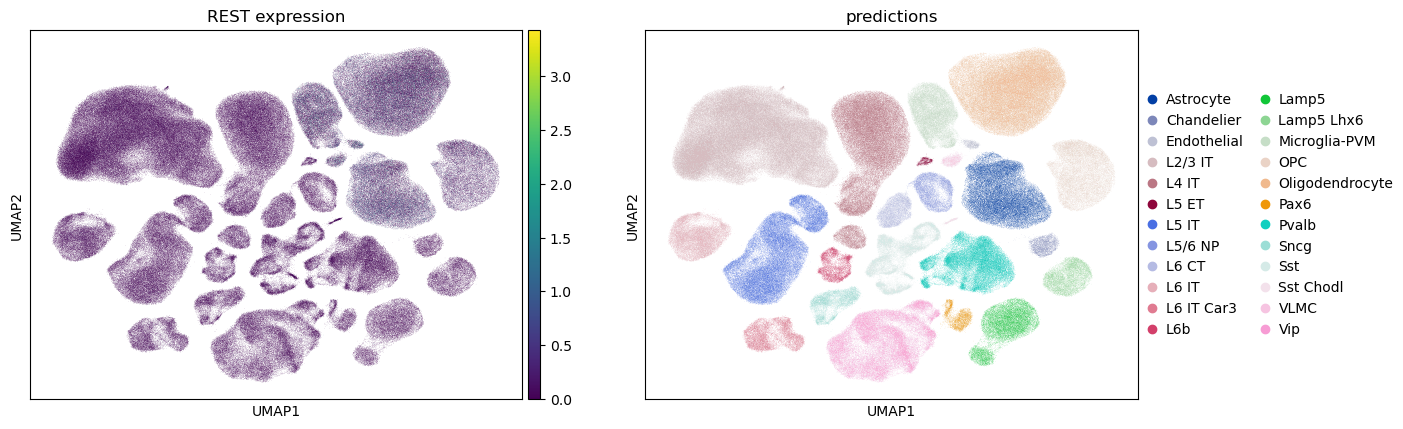

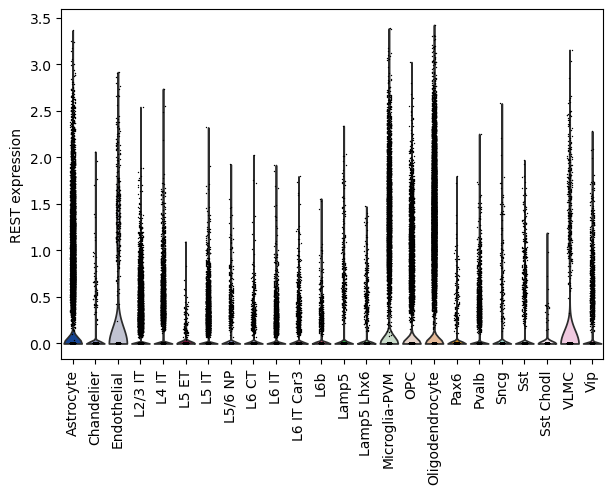

In [32]:
sc.pl.umap(adata_query_X, color=[tf, "predictions"], title=[f"{tf} expression", "predictions"])
sc.pl.violin(adata_query_X, keys=[tf], groupby="predictions", rotation=90, ylabel=f"{tf} expression")